In [1]:
# Now let's all the necessary libraries here 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
import keras 
import keras_tuner as kt

from keras.callbacks import EarlyStopping
from keras.optimizers import Adam,SGD,RMSprop
from keras.models import Sequential
from keras.layers import Input,Activation
from keras.layers import Dropout,Dense,BatchNormalization

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df.shape

(1338, 7)

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
# This is also one of the famous dataset so we just need to map sex and age into binary and make seperate columns for region usng onc 

In [7]:
df['sex'] = df['sex'].map({
                                'female': 0,
                                'male' : 1
})

In [8]:
df['smoker'] = df['smoker'].map({
                                'no': 0,
                                'yes' : 1
})

In [9]:
df = pd.get_dummies(df,columns=['region'],dtype=int) # OneHotEncode using get_dummmies

In [10]:
df.head() # All set

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


In [11]:
# I also want to see the corr of the values with charges
df.corr()['charges'] # We won't remove the non significant columns here for now ; maybe later during experimenting

age                 0.299008
sex                 0.057292
bmi                 0.198341
children            0.067998
smoker              0.787251
charges             1.000000
region_northeast    0.006349
region_northwest   -0.039905
region_southeast    0.073982
region_southwest   -0.043210
Name: charges, dtype: float64

In [173]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='str')

In [12]:
# Now we will split the data into X,y and then training and testing set for our ann

In [192]:
X,y = df.drop(columns=['charges']),df['charges']

In [193]:
X_train , X_test , y_train , y_test = train_test_split(
                                                            X,y,
                                                            test_size = 0.2,
                                                            random_state = 42
)

In [194]:
# Now we have one last step left that is Normalization which we will do using StandardScaler
scale = StandardScaler()
scale.fit(X_train)

X_train_scalled = scale.transform(X_train)
X_test_scalled = scale.transform(X_test)

In [195]:
# Now we are readly for the model building phase

In [196]:
# We will be using the linear model for the outpu layer
# Hidden Layer = 2 for now and the Activation will be relu
# No of neurons will be 12 for each layer now

In [ ]:
model = Sequential()

n_layers = 2

for _ in range(n_layers) :
    model.add(Dense(30,kernel_initializer='he_normal'))
    model.add(Activation('relu'))
    model.add(Dropout(0.3))

model.add(Dense(1))
model.add(Activation('linear'))

model.compile(optimizer='adam',loss='mean_squared_error',metrics=['mae','root_mean_squared_error'])

In [214]:
stop_early = EarlyStopping(
    monitor='val_root_mean_squared_error',       
    patience=10,                     
    restore_best_weights=True
)

In [215]:
history = model.fit(
            X_train,y_train,
            epochs = 100,
            validation_data = (X_test,y_test),
            verbose = 1,
            callbacks=stop_early
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 322447552.0000 - mae: 13345.9717 - root_mean_squared_error: 17956.8242 - val_loss: 323380896.0000 - val_mae: 12966.7334 - val_root_mean_squared_error: 17982.7949
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 322440320.0000 - mae: 13345.7129 - root_mean_squared_error: 17956.6230 - val_loss: 323373024.0000 - val_mae: 12966.5127 - val_root_mean_squared_error: 17982.5762
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 322427072.0000 - mae: 13345.4248 - root_mean_squared_error: 17956.2539 - val_loss: 323362144.0000 - val_mae: 12966.2490 - val_root_mean_squared_error: 17982.2734
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 322417344.0000 - mae: 13345.0684 - root_mean_squared_error: 17955.9844 - val_loss: 323350848.0000 - val_mae: 12966.0137 - val_root_mean_squared_error: 17981.9590
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 322397760.0000 - mae: 13344.6191 - root_mean_squared

In [216]:
# def build_model(hp):

#     model = Sequential()

#     model.add(Input(shape=(X.shape[1],)))

#     num_layers = hp.Int(
#                             'no_of_layers',
#                             min_value = 2,
#                             max_value = 5,
#                             step = 1
#     )

#     for i in range(num_layers):

#         num_neurons = hp.Int(
#                             f'no_of_nodes_{i}',
#                             min_value = 10,
#                             max_value = 20,
#                             step = 5
#         )


#         model.add(Dense(num_neurons,kernel_initializer='he_normal'))

#         model.add(BatchNormalization())

#         model.add(Activation('relu'))

#         dropout_rate = hp.Float(
#                                     f'dropout_{i}', 
#                                     min_value=0.0, 
#                                     max_value=0.6, 
#                                     step=0.2
#         )
        
#         model.add(Dropout(dropout_rate))

#     model.add(Dense(1))
#     model.add(Activation('linear'))


#     learning_rate = hp.Choice(
#                                 'learning_rates' ,         
#                                 values = [1e-2, 1e-3, 1e-4] 
#         )


#     optimizer_name = hp.Choice(
#                                 'optimizer_engine',
#                                 values=['adam', 'rmsprop']
#                                 )

#     if optimizer_name == 'adam':
#         optimizer = Adam(learning_rate=learning_rate)
#     else:
#         optimizer = RMSprop(learning_rate=learning_rate)

#     model.compile(
#         optimizer= optimizer,
#         loss='mean_squared_error',
#         metrics=['mae','root_mean_squared_error']
#     )

#     return model



In [217]:
# # Hyperband 
# tuner = kt.Hyperband(
#                         hypermodel = build_model,
#                         objective = 'val_root_mean_squared_error',
#                         max_epochs = 20,
#                         factor = 2,
#                         directory = 'insurance_tuning',
#                         project_name = 'neural-network-insurance-1'
# )

In [218]:
# stop_early = EarlyStopping(
#     monitor='val_root_mean_squared_error',       
#     patience=5,                     
#     restore_best_weights=True
# )

In [219]:
# tuner.search(
#     X_train, y_train,                         
#     validation_data=(X_test,y_test),   
#     callbacks=[stop_early]              
# )

In [220]:
# tuner.results_summary(num_trials=1)

In [221]:
# best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
# best_model = tuner.hypermodel.build(best_hps)

In [222]:
# history = best_model.fit(
#     X_train, y_train, 
#     epochs=100, 
#     validation_data=(X_test, y_test),
#     callbacks=[stop_early]
# )

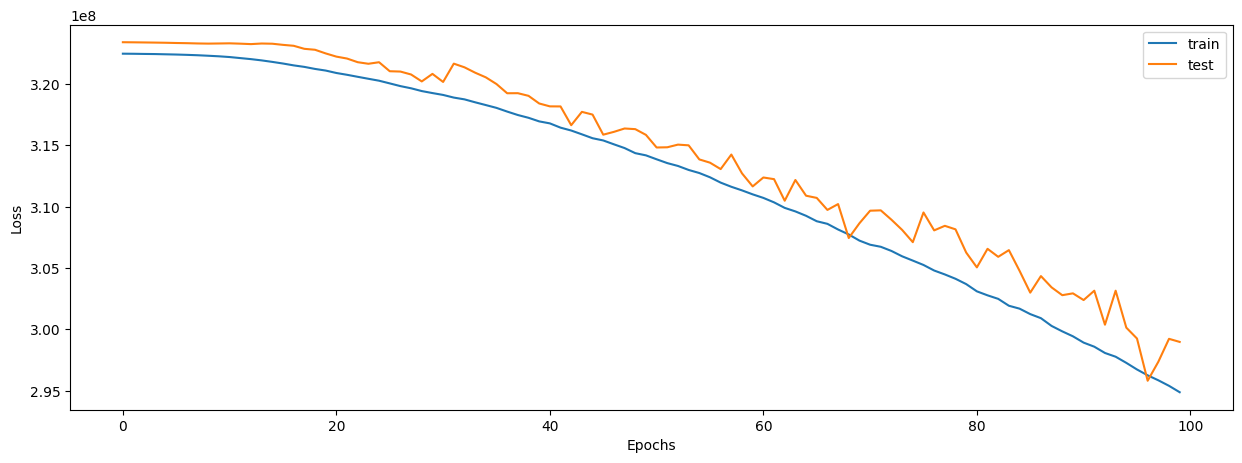

In [223]:
# Plot the model performance 
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

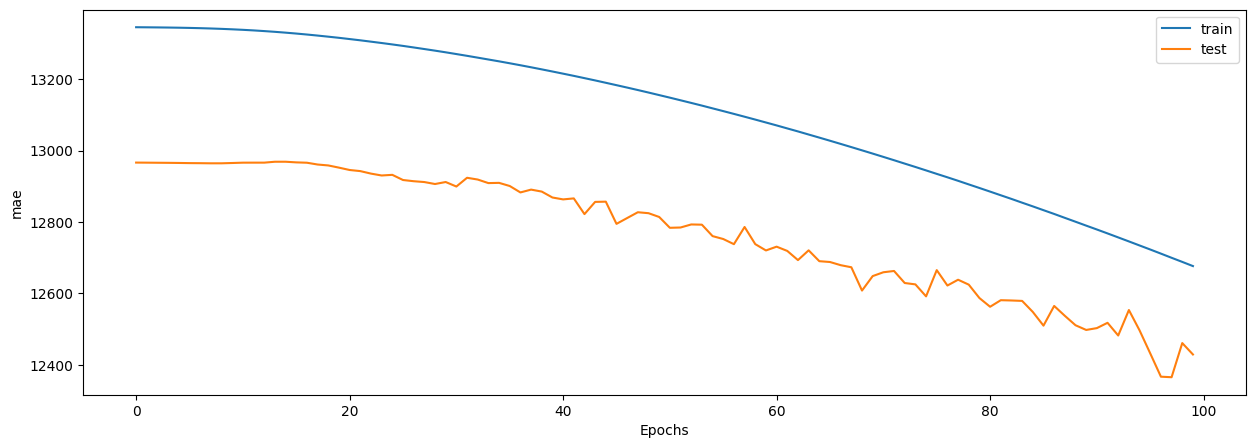

In [224]:
# Plot the model performance 
plt.figure(figsize=(15,5))
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='test')
plt.xlabel('Epochs')
plt.ylabel('mae')
plt.legend()
plt.show()

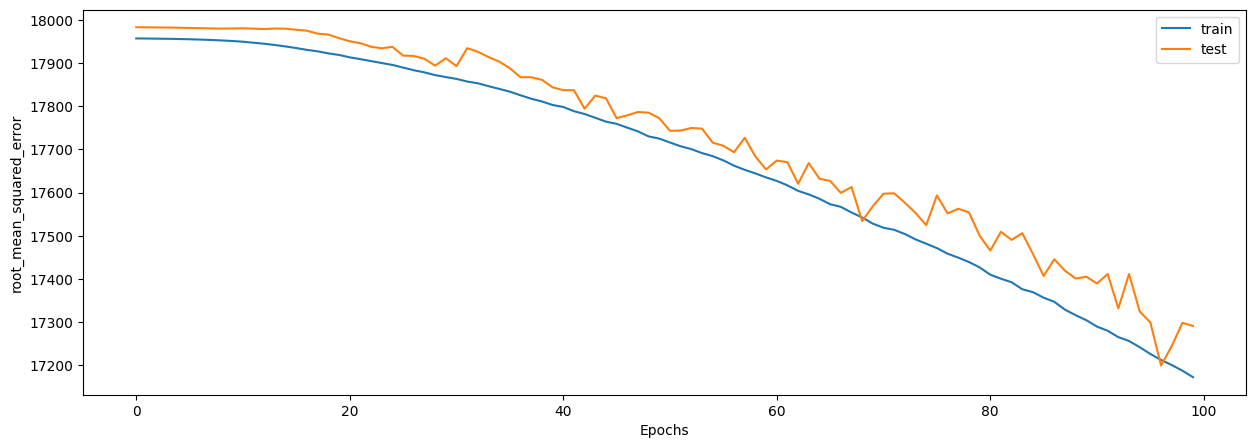

In [225]:
# Plot the model performance 
plt.figure(figsize=(15,5))
plt.plot(history.history['root_mean_squared_error'], label='train')
plt.plot(history.history['val_root_mean_squared_error'], label='test')
plt.xlabel('Epochs')
plt.ylabel('root_mean_squared_error')
plt.legend()
plt.show()